# Predict wheather there will be rainfall on the particular day

In [1]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler


In [4]:
# # Load your data
# data = pd.read_csv('whether_data.csv')

In [5]:
# # Example preprocessing steps (fill missing values with mean)
# data = data.fillna(data.mean(numeric_only=True))

In [6]:
# # Split into features (X) and target (y)
# X = data.drop('RainfallTomorrow', axis=1)
# y = data['RainfallTomorrow']

KeyError: "['RainfallTomorrow'] not found in axis"

In [7]:
# ## Scale features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

NameError: name 'X' is not defined

In [8]:

# # Split into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


NameError: name 'X_scaled' is not defined

# Exploratory Data Analysis (EDA)

In [9]:
# from sklearn.ensemble import RandomForestClassifier

# # Initialize the model
# model = RandomForestClassifier(random_state=42)

# # Train the model
# model.fit(X_train, y_train)


NameError: name 'X_train' is not defined

# Model Evaluation

In [10]:
# from sklearn.metrics import accuracy_score, classification_report

# # Predict on the test set
# y_pred = model.predict(X_test)

# # Evaluate performance
# accuracy = accuracy_score(y_test, y_pred)
# report = classification_report(y_test, y_pred)

# print(f"Accuracy: {accuracy}")
# print(f"Classification Report:\n{report}")


NameError: name 'X_test' is not defined

In [11]:
# #Hyperparameter Tuning
# from sklearn.model_selection import GridSearchCV

# # Define a grid of parameters to search
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 10, 20, 30]
# }

# # Initialize Grid Search with cross-validation
# grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# # Fit Grid Search to the data
# grid_search.fit(X_train, y_train)

# # Best parameters and best score
# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best score: {grid_search.best_score_}")


NameError: name 'X_train' is not defined

# Feature Importance

In [12]:
# # Get feature importances from the best model after tuning
# best_model = grid_search.best_estimator_
# importances = best_model.feature_importances_
# feature_names = X.columns

# # Display feature importances
# feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)
# print(f"Feature Importances:\n{feature_importance_df}")


AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

# Actual Answer question 3

# Rainfall Prediction 


In [3]:
# Import Required Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc 
# ML Models 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 

In [5]:
# Load Dataset 
df = pd.read_csv('whether_data.csv')

# Exploratory Data Analysis (EDA) 

In [6]:
print("First 5 Rows:") 
print(df.head()) 
print("\nDataset Info:") 
print(df.info()) 
print("\nStatistical Summary:") 
print(df.describe())

First 5 Rows:
       DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
0  20000101      1                  8            0.89          1.0286   
1  20000102      1                  8            0.87          1.0318   
2  20000103      1                  5            0.81          1.0314   
3  20000104      1                  7            0.79          1.0262   
4  20000105      1                  5            0.90          1.0246   

   BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
0                    0.20                 0.03             0.0   
1                    0.25                 0.00             0.0   
2                    0.50                 0.00             3.7   
3                    0.63                 0.35             6.9   
4                    0.51                 0.07             3.7   

   BASEL_temp_mean  BASEL_temp_min  ...  STOCKHOLM_temp_min  \
0              2.9             1.6  ...                -9.3   
1              3.6      

In [7]:
# Check missing values 
print("\nMissing Values:") 
print(df.isnull().sum()) 


Missing Values:
DATE                      0
MONTH                     0
BASEL_cloud_cover         0
BASEL_humidity            0
BASEL_pressure            0
                         ..
TOURS_global_radiation    0
TOURS_precipitation       0
TOURS_temp_mean           0
TOURS_temp_min            0
TOURS_temp_max            0
Length: 165, dtype: int64


In [8]:
# Handle Missing Values 
df.fillna(df.mean(numeric_only=True), inplace=True) 

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,20091228,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,...,-2.7,2.4,3.7,0.95,1.0011,0.22,1.50,6.2,1.8,10.6
3650,20091229,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,...,-9.5,0.8,5.3,0.89,0.9966,0.24,0.40,10.4,6.2,14.5
3651,20091230,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,...,-12.5,-7.4,3.8,0.88,0.9939,0.24,1.00,10.0,8.7,11.3
3652,20091231,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,...,-9.3,-6.5,4.2,0.88,0.9933,0.58,0.02,8.5,6.2,10.9


In [9]:
# Encode Categorical Variables 
label_encoder = LabelEncoder() 
for column in df.select_dtypes(include=['object']).columns: 
    df[column] = label_encoder.fit_transform(df[column])

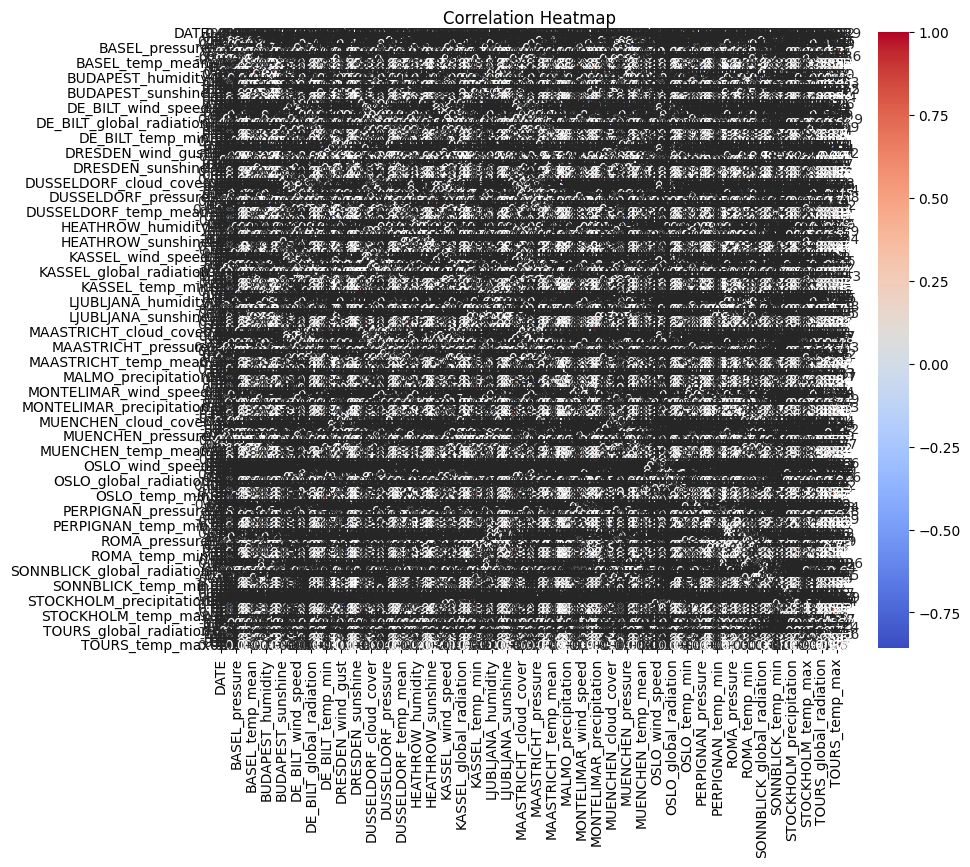

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10,8)) 
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') 
plt.title("Correlation Heatmap") 
plt.show() 

In [11]:
# Rainfall Distribution
sns.countplot(x='RainToday', data=df) 
plt.title("Rainfall Class Distribution") 
plt.show() 

ValueError: Could not interpret value `RainToday` for `x`. An entry with this name does not appear in `data`.

# Data Preprocessing

In [12]:
X = df.drop('RainToday', axis=1) 
y = df['RainToday']

KeyError: "['RainToday'] not found in axis"

In [13]:
# Feature Scaling 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

NameError: name 'X' is not defined

In [14]:
# Train Test Split (80-20) 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

NameError: name 'X_scaled' is not defined

# Model Building 

In [15]:
models = { 
    "Logistic Regression": LogisticRegression(), 
    "Decision Tree": DecisionTreeClassifier(), 
    "Random Forest": RandomForestClassifier(), 
    "SVM": SVC(probability=True), 
    "KNN": KNeighborsClassifier(), 
    "Gradient Boosting": GradientBoostingClassifier() 
} 
 
results = [] 
 
for name, model in models.items(): 
 
    model.fit(X_train, y_train) 
 
    y_pred = model.predict(X_test) 
 
    acc = accuracy_score(y_test, y_pred) 
 
    print("\nModel:", name) 
    print("Accuracy:", acc) 
 
    print("\nConfusion Matrix:") 
    print(confusion_matrix(y_test, y_pred)) 
 
    print("\nClassification Report:") 
    print(classification_report(y_test, y_pred)) 
 
    results.append([name, acc])

NameError: name 'X_train' is not defined


Model Accuracy Comparison:
Empty DataFrame
Columns: [Model, Accuracy]
Index: []


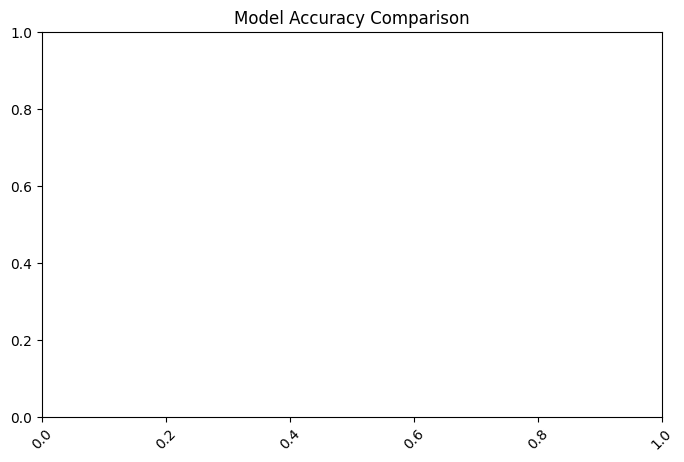

In [16]:
#Model Comparison
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy']) 
print("\nModel Accuracy Comparison:") 
print(results_df) 
plt.figure(figsize=(8,5)) 
sns.barplot(x='Model', y='Accuracy', data=results_df) 
plt.xticks(rotation=45) 
plt.title("Model Accuracy Comparison") 
plt.show() 

In [17]:
#ROC Curve (Example using Random Forest)
rf = RandomForestClassifier() 
rf.fit(X_train, y_train) 
y_prob = rf.predict_proba(X_test)[:,1] 
fpr, tpr, threshold = roc_curve(y_test, y_prob) 
roc_auc = auc(fpr, tpr) 
plt.plot(fpr, tpr, label="AUC="+str(roc_auc)) 
plt.plot([0,1],[0,1],'--') 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title("ROC Curve") 
plt.legend() 
plt.show()

NameError: name 'X_train' is not defined

# Hyperparameter Tuning (Random Forest) 

In [18]:
param_grid = { 
    'n_estimators':[100,200], 
    'max_depth':[5,10,20] 
} 
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5) 
grid.fit(X_train, y_train) 
print("\nBest Parameters:", grid.best_params_) 
best_model = grid.best_estimator_

NameError: name 'X_train' is not defined

In [19]:
# Prediction using tuned model 
y_pred_best = best_model.predict(X_test) 
print("\nAccuracy after tuning:", accuracy_score(y_test, y_pred_best)) 


NameError: name 'best_model' is not defined

# Feature Importance 

In [20]:
importances = best_model.feature_importances_ 
features = X.columns 
feature_df = pd.DataFrame({ 
    'Feature':features, 
    'Importance':importances 
}).sort_values(by='Importance', ascending=False) 
print("\nFeature Importance:") 
print(feature_df) 
plt.figure(figsize=(10,6)) 
sns.barplot(x='Importance', y='Feature', data=feature_df) 
plt.title("Feature Importance for Rainfall Prediction") 
plt.show() 

NameError: name 'best_model' is not defined

In [21]:
# Final Prediction Example 
sample = X_test[0].reshape(1,-1) 
prediction = best_model.predict(sample) 
print("\nFinal Prediction (0 = No Rain, 1 = Rain):", prediction)

NameError: name 'X_test' is not defined